# 3. Decision Trees - Football Match Outcome Prediction

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DT_football.csv to DT_football.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

In [ ]:
df = pd.read_csv("DT_football.csv")
X = df.drop("result", axis=1).values
y = df["result"].values
feature_names = df.drop("result", axis=1).columns.tolist()

# continuous features need threshold search; categorical use unique values
CONTINUOUS = {"possession_pct", "pass_accuracy_pct", "distance_covered_km", "xG"}
continuous_idx = {i for i, f in enumerate(feature_names) if f in CONTINUOUS}

np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]


In [ ]:
def entropy(y):
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y.astype(int))
    probs = counts / len(y)
    # ignore zero probabilities (0 * log(0) = 0)
    return -sum(p * np.log2(p) for p in probs if p > 0)

def information_gain(y, y_left, y_right):
    n = len(y)
    weighted = (len(y_left) / n) * entropy(y_left) + (len(y_right) / n) * entropy(y_right)
    return entropy(y) - weighted

In [ ]:
def best_split(X, y):
    best_ig, best_feat, best_thresh = -1, None, None

    for feat_idx in range(X.shape[1]):
        col = X[:, feat_idx]

        if feat_idx in continuous_idx:
            # midpoint thresholds between consecutive sorted unique values
            unique_sorted = np.sort(np.unique(col))
            thresholds = (unique_sorted[:-1] + unique_sorted[1:]) / 2
        else:
            # categorical: split on each unique value (== value vs != value)
            thresholds = np.unique(col)

        for thresh in thresholds:
            if feat_idx in continuous_idx:
                mask = col <= thresh
            else:
                mask = col == thresh

            y_left, y_right = y[mask], y[~mask]
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            ig = information_gain(y, y_left, y_right)
            if ig > best_ig:
                best_ig, best_feat, best_thresh = ig, feat_idx, thresh

    return best_feat, best_thresh

In [ ]:
class Node:
    def __init__(self, feat=None, thresh=None, left=None, right=None, label=None):
        self.feat = feat        # feature index for split
        self.thresh = thresh    # split threshold/value
        self.left = left        # left subtree  (condition True)
        self.right = right      # right subtree (condition False)
        self.label = label      # set only for leaf nodes

    def is_leaf(self):
        return self.label is not None

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._build(X, y, depth=0)

    def _build(self, X, y, depth):
        # stop conditions → leaf
        if len(np.unique(y)) == 1:
            return Node(label=int(y[0]))
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(label=int(Counter(y).most_common(1)[0][0]))
        if len(y) == 0:
            return Node(label=0)

        feat, thresh = best_split(X, y)
        if feat is None:
            return Node(label=int(Counter(y).most_common(1)[0][0]))

        if feat in continuous_idx:
            mask = X[:, feat] <= thresh
        else:
            mask = X[:, feat] == thresh

        left  = self._build(X[mask],  y[mask],  depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)
        return Node(feat=feat, thresh=thresh, left=left, right=right)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.label
        if node.feat in continuous_idx:
            go_left = x[node.feat] <= node.thresh
        else:
            go_left = x[node.feat] == node.thresh
        return self._predict_one(x, node.left if go_left else node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    # count leaf nodes
    def count_leaves(self, node=None):
        if node is None:
            node = self.root
        if node.is_leaf():
            return 1
        return self.count_leaves(node.left) + self.count_leaves(node.right)

    # pretty-print the tree structure
    def print_tree(self, node=None, depth=0, prefix="Root"):
        if node is None:
            node = self.root
        indent = "    " * depth
        if node.is_leaf():
            print(f"{indent}{prefix} → Predict: {node.label}")
            return
        fname = feature_names[node.feat]
        op = "<=" if node.feat in continuous_idx else "=="
        print(f"{indent}{prefix} [{fname} {op} {node.thresh:.4f}]")
        self.print_tree(node.left,  depth + 1, prefix="T")
        self.print_tree(node.right, depth + 1, prefix="F")


In [ ]:
print("=" * 60)
print("PART (a): Full Decision Tree")
print("=" * 60)

dt_full = DecisionTree(max_depth=None)
dt_full.fit(X_train, y_train)

train_acc_full = dt_full.accuracy(X_train, y_train)
test_acc_full  = dt_full.accuracy(X_test,  y_test)
print(f"Train Accuracy : {train_acc_full:.4f}")
print(f"Test  Accuracy : {test_acc_full:.4f}")
print(f"Leaf Nodes     : {dt_full.count_leaves()}\n")
print("Tree Structure (first 4 levels shown to keep output manageable):")

# print only first few levels so output isn't thousands of lines
def print_tree_pretty(node, prefix="", is_left=None, depth=0, max_show=4):
    if node is None or depth > max_show:
        return

    # choose the branch symbol
    if is_left is None:
        branch = ""          # root node
    elif is_left:
        branch = "├── YES: "
    else:
        branch = "└── NO : "

    if node.is_leaf():
        print(f"{prefix}{branch}Predict: {node.label}")
        return

    fname = feature_names[node.feat]
    op = "<=" if node.feat in continuous_idx else "=="
    print(f"{prefix}{branch}Is {fname} {op} {node.thresh:.4f}?")

    # child prefix: if this node used ├──, children need │ to continue the vertical line
    child_prefix = prefix + ("│   " if is_left else "    ")

    print_tree_pretty(node.left,  child_prefix, is_left=True,  depth=depth+1, max_show=max_show)
    print_tree_pretty(node.right, child_prefix, is_left=False, depth=depth+1, max_show=max_show)

print_tree_pretty(dt_full.root, max_show=4)

PART (a): Full Decision Tree
Train Accuracy : 1.0000
Test  Accuracy : 0.6875
Leaf Nodes     : 162

Tree Structure (first 4 levels shown to keep output manageable):
Is possession_pct <= 51.9750?
    ├── YES: Is xG <= 1.4400?
    │   ├── YES: Is pass_accuracy_pct <= 76.3200?
    │   │   ├── YES: Is xG <= 0.8460?
    │   │   │   ├── YES: Is shots_on_target == 13.0000?
    │   │   │   └── NO : Is defensive_errors == 0.0000?
    │   │   └── NO : Is xG <= 0.2890?
    │   │       ├── YES: Is xG <= 0.2400?
    │   │       └── NO : Is defensive_errors == 6.0000?
    │   └── NO : Is defensive_errors == 7.0000?
    │       ├── YES: Is home_away == 0.0000?
    │       │   ├── YES: Predict: 0
    │       │   └── NO : Is possession_pct <= 35.7750?
    │       └── NO : Is shots_on_target == 1.0000?
    │           ├── YES: Is xG <= 3.4445?
    │           └── NO : Is shots_on_target == 0.0000?
    └── NO : Is defensive_errors == 7.0000?
        ├── YES: Is possession_pct <= 66.1350?
        │   ├── Y

In [ ]:
print("PART (b): Depth Hyperparameter Tuning")

# 80/20 split of training data for validation
val_split = int(0.8 * len(X_train))
val_idx = np.random.permutation(len(X_train))
X_tr  = X_train[val_idx[:val_split]]
y_tr  = y_train[val_idx[:val_split]]
X_val = X_train[val_idx[val_split:]]
y_val = y_train[val_idx[val_split:]]

depths      = [1, 2, 3, 5, 7, 10, 15, None]
tr_accs     = []
val_accs    = []
leaf_counts = []

for d in depths:
    dt = DecisionTree(max_depth=d)
    dt.fit(X_tr, y_tr)
    tr_accs.append(dt.accuracy(X_tr, y_tr))
    val_accs.append(dt.accuracy(X_val, y_val))
    leaf_counts.append(dt.count_leaves())

print(f"{'Depth':<8} {'Train Acc':>10} {'Val Acc':>10} {'Leaves':>8}")
print("-" * 40)
for d, ta, va, lc in zip(depths, tr_accs, val_accs, leaf_counts):
    print(f"{str(d):<8} {ta:>10.4f} {va:>10.4f} {lc:>8}")

# optimal depth = highest validation accuracy
best_idx   = int(np.argmax(val_accs))
opt_depth  = depths[best_idx]
print(f"\nOptimal depth: {opt_depth}  (val acc = {val_accs[best_idx]:.4f})")


PART (b): Depth Hyperparameter Tuning
Depth     Train Acc    Val Acc   Leaves
----------------------------------------
1            0.6576     0.6302        2
2            0.7161     0.6771        4
3            0.7435     0.6667        8
5            0.8164     0.6406       25
7            0.8737     0.6615       51
10           0.9596     0.6979       98
15           1.0000     0.6719      129
None         1.0000     0.6719      129

Optimal depth: 10  (val acc = 0.6979)


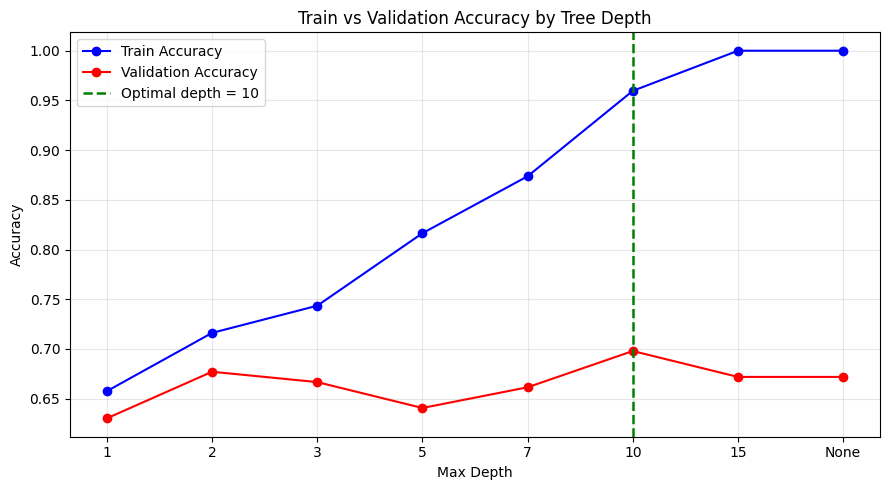

In [ ]:
x_labels = [str(d) for d in depths]
x_pos    = list(range(len(depths)))

# ── Plot 1: accuracy vs depth ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_pos, tr_accs,  "b-o", label="Train Accuracy")
ax.plot(x_pos, val_accs, "r-o", label="Validation Accuracy")
ax.axvline(x=best_idx, color="green", linestyle="--", linewidth=1.8, label=f"Optimal depth = {opt_depth}")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy by Tree Depth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("plot1_accuracy_vs_depth.png", dpi=150)
plt.close()

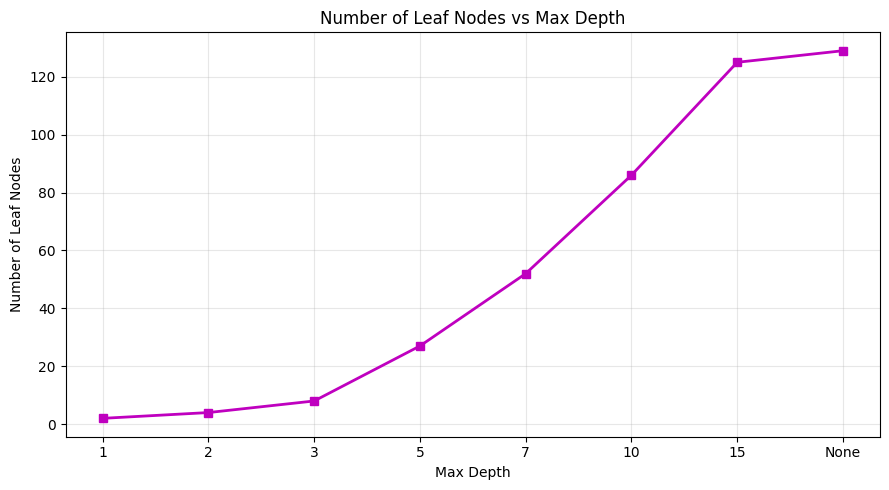

In [ ]:
# ── Plot 2: leaf nodes vs depth ────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_pos, leaf_counts, "m-s", linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Max Depth")
ax.set_ylabel("Number of Leaf Nodes")
ax.set_title("Number of Leaf Nodes vs Max Depth")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("plot2_leaves_vs_depth.png", dpi=150)
plt.close()


In [ ]:
# retrain on full training set with optimal depth
dt_opt = DecisionTree(max_depth=opt_depth)
dt_opt.fit(X_train, y_train)
test_acc_opt = dt_opt.accuracy(X_test, y_test)
print(f"Test accuracy with optimal depth ({opt_depth}): {test_acc_opt:.4f}")

Test accuracy with optimal depth (7): 0.6750


In [ ]:
print("\n" + "=" * 60)
print("PART (c): Reduced Error Pruning")
print("=" * 60)

# hold out 20% of training set as pruning validation set
prune_split = int(0.8 * len(X_train))
prune_idx   = np.random.permutation(len(X_train))
X_grow  = X_train[prune_idx[:prune_split]]
y_grow  = y_train[prune_idx[:prune_split]]
X_prune = X_train[prune_idx[prune_split:]]
y_prune = y_train[prune_idx[prune_split:]]

# grow a full tree on the 80% portion
dt_before = DecisionTree(max_depth=None)
dt_before.fit(X_grow, y_grow)

before_train_acc = dt_before.accuracy(X_grow,  y_grow)
before_prune_acc = dt_before.accuracy(X_prune, y_prune)
before_test_acc  = dt_before.accuracy(X_test,  y_test)

print(f"BEFORE Pruning — Train: {before_train_acc:.4f} | Prune-Val: {before_prune_acc:.4f} | Test: {before_test_acc:.4f}")


PART (c): Reduced Error Pruning
BEFORE Pruning — Train: 1.0000 | Prune-Val: 0.7031 | Test: 0.7000


In [ ]:
def majority_label(node, X_sub, y_sub):
    """Predict with a temporary leaf (majority class of subtree's training data)."""
    # collect all labels routed through this node on prune set
    preds = np.array([_traverse(x, node) for x in X_sub])
    return preds

def _traverse(x, node):
    if node.is_leaf():
        return node.label
    if node.feat in continuous_idx:
        go_left = x[node.feat] <= node.thresh
    else:
        go_left = x[node.feat] == node.thresh
    return _traverse(x, node.left if go_left else node.right)

def _majority(y_arr):
    return int(Counter(y_arr.astype(int)).most_common(1)[0][0])

def prune(node, X_prune, y_prune):
    """Recursively prune bottom-up; returns (possibly replaced) node."""
    if node.is_leaf():
        return node

    # recurse first (bottom-up)
    node.left  = prune(node.left,  X_prune, y_prune)
    node.right = prune(node.right, X_prune, y_prune)

    # current accuracy on prune set using this subtree
    preds_before = np.array([_traverse(x, node) for x in X_prune])
    acc_before = np.mean(preds_before == y_prune)

    # majority class label from subtree predictions on prune set
    leaf_label = _majority(preds_before)

    # accuracy if we replace this node with a leaf
    acc_leaf = np.mean(leaf_label == y_prune)

    if acc_leaf >= acc_before:
        return Node(label=leaf_label)   # prune: replace with leaf

    return node

import copy
dt_pruned_tree = copy.deepcopy(dt_before)
dt_pruned_tree.root = prune(dt_pruned_tree.root, X_prune, y_prune)

after_train_acc = dt_pruned_tree.accuracy(X_grow,  y_grow)
after_prune_acc = dt_pruned_tree.accuracy(X_prune, y_prune)
after_test_acc  = dt_pruned_tree.accuracy(X_test,  y_test)

print(f"AFTER  Pruning — Train: {after_train_acc:.4f} | Prune-Val: {after_prune_acc:.4f} | Test: {after_test_acc:.4f}")

AFTER  Pruning — Train: 0.9010 | Prune-Val: 0.7500 | Test: 0.7083


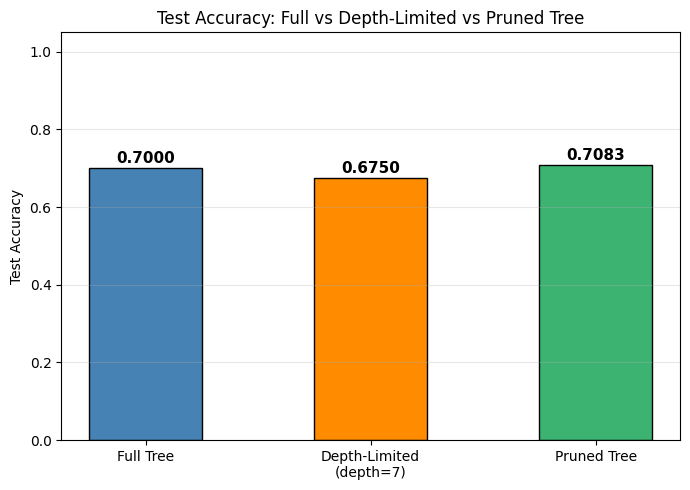

In [ ]:
# ── Bar chart: full vs depth-limited vs pruned ─
labels = ["Full Tree", f"Depth-Limited\n(depth={opt_depth})", "Pruned Tree"]
accs   = [before_test_acc, test_acc_opt, after_test_acc]
colors = ["steelblue", "darkorange", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, accs, color=colors, width=0.5, edgecolor="black")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy: Full vs Depth-Limited vs Pruned Tree")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("plot3_model_comparison.png", dpi=150)
plt.close()